In [1]:
print("hello")

hello


In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
data = pd.read_csv("weather_condition_classification_logreg.csv")
data.head()

,Record_ID,Observation_Date,Temperature_C,Humidity_pct,Pressure_hPa,WindSpeed_kmh,Visibility_km,Precipitation_mm,Elevation_m,CloudCover_pct,Region,Season,TimeOfDay,Station_Type,Cold_Front,Storm_Alert,Target_Column
0,1,2025-11-24,21.78,72.36,1016.34,16.13,6.23,0.00,396.46,50.73,North,Autumn,Morning,Urban,False,True,0
1,2,2025-04-23,33.56,79.81,1027.71,14.78,4.84,2.07,544.27,62.06,East,Spring,Morning,Urban,False,False,0
2,3,2025-01-23,1.59,100.00,1006.19,21.46,5.97,5.51,122.37,64.46,Coastal,Winter,Morning,Urban,False,False,1
3,4,2025-05-23,27.92,86.94,1009.78,9.67,8.18,4.08,88.00,77.22,East,Spring,Afternoon,Urban,False,False,0
4,5,2025-10-13,21.77,96.30,1025.03,19.74,5.60,5.29,955.55,80.65,South,Autumn,Evening,Urban,False,False,1


In [6]:
data.drop(["Observation_Date"], axis=1, inplace=True)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         1000 non-null   int64  
 1   Temperature_C     1000 non-null   float64
 2   Humidity_pct      1000 non-null   float64
 3   Pressure_hPa      1000 non-null   float64
 4   WindSpeed_kmh     1000 non-null   float64
 5   Visibility_km     1000 non-null   float64
 6   Precipitation_mm  1000 non-null   float64
 7   Elevation_m       1000 non-null   float64
 8   CloudCover_pct    1000 non-null   float64
 9   Region            1000 non-null   str    
 10  Season            1000 non-null   str    
 11  TimeOfDay         1000 non-null   str    
 12  Station_Type      1000 non-null   str    
 13  Cold_Front        1000 non-null   bool   
 14  Storm_Alert       1000 non-null   bool   
 15  Target_Column     1000 non-null   int64  
dtypes: bool(2), float64(8), int64(2), str(4)
memory usage:

<class 'pandas.DataFrame'>
Index: 463 entries, 2 to 999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         463 non-null    int64  
 1   Observation_Date  463 non-null    str    
 2   Temperature_C     463 non-null    float64
 3   Humidity_pct      463 non-null    float64
 4   Pressure_hPa      463 non-null    float64
 5   WindSpeed_kmh     463 non-null    float64
 6   Visibility_km     463 non-null    float64
 7   Precipitation_mm  463 non-null    float64
 8   Elevation_m       463 non-null    float64
 9   CloudCover_pct    463 non-null    float64
 10  Region            463 non-null    str    
 11  Season            463 non-null    str    
 12  TimeOfDay         463 non-null    str    
 13  Station_Type      463 non-null    str    
 14  Cold_Front        463 non-null    object 
 15  Storm_Alert       463 non-null    object 
 16  Target_Column     463 non-null    int64  
dtypes: float64(8)

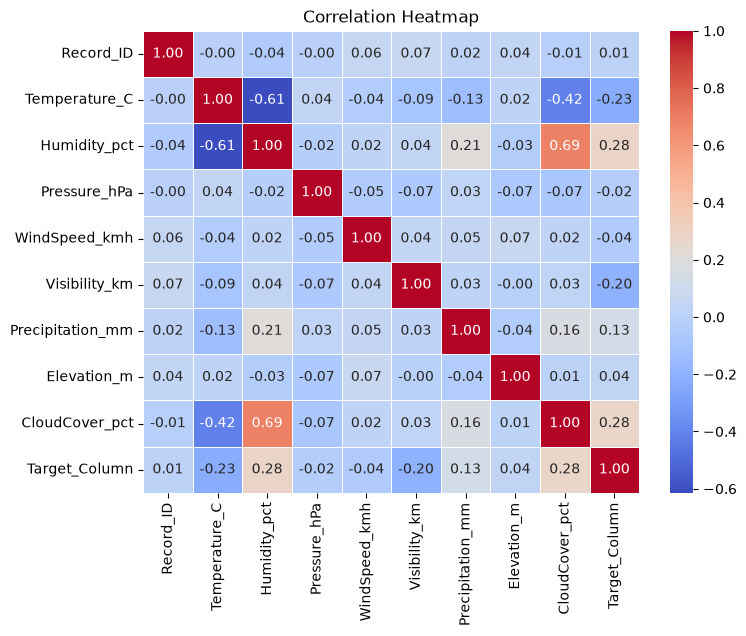

In [11]:
plt.figure(figsize=(8, 6))
numeric_cols = data.select_dtypes(include=[np.number]).columns
correlation_matrix = data[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [12]:
data.describe()

,Record_ID,Temperature_C,Humidity_pct,Pressure_hPa,WindSpeed_kmh,Visibility_km,Precipitation_mm,Elevation_m,CloudCover_pct,Target_Column
count,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000
mean,527.125270,20.032818,57.857793,1012.901610,15.469093,7.812836,1.191635,582.125628,48.134598,0.207343
std,293.568265,9.864230,12.883922,7.503602,8.571124,2.958925,1.696767,530.663995,19.980989,0.405842
min,3.000000,-15.000000,16.725141,989.342568,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000
25%,277.000000,13.011537,49.454517,1007.979094,9.463044,5.724752,0.000000,91.220758,35.215423,0.000000
50%,539.000000,20.234415,57.670021,1012.840439,14.876303,7.954204,0.042481,483.234750,47.909628,0.000000
75%,786.000000,27.474501,66.411851,1017.827181,20.699682,9.798713,1.932218,894.266778,60.839479,0.000000
max,1000.000000,45.000000,98.503050,1035.635798,70.581688,17.196192,9.894379,2597.246305,100.000000,1.000000


In [13]:
data.head(2)

,Record_ID,Observation_Date,Temperature_C,Humidity_pct,Pressure_hPa,WindSpeed_kmh,Visibility_km,Precipitation_mm,Elevation_m,CloudCover_pct,Region,Season,TimeOfDay,Station_Type,Cold_Front,Storm_Alert,Target_Column
2,3,2025-09-11,11.292603,61.962714,1006.996030,2.870297,14.54865,0.00000,0.00000,68.754933,Mountain,Summer,Morning,urban,False,False,0
6,7,2025-08-24,32.376812,40.217236,1002.979075,6.821267,3.59452,3.94889,1859.68848,20.259614,East,Summer,Afternoon,URBAN,False,False,0


In [ ]:
numeric_features = ['Study_Hours', 'Previous_Scores', 'Sleep_Hours']
nominal_features = ['Extracurricular_Activities', 'Internet_Access']
ordinal_features = ['Student_Motivation_Level']